# DC Resistivity Inversion: Depth to Basement

RBF level-set inversion for a synthetic 2D DC resistivity model with
an undulating conductive basement, a resistive cover, and an embedded
resistive lens. Compares the result against a conventional smooth L2
inversion.

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse as sp
from scipy.spatial import cKDTree

from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz

from simpeg import (
    maps, data as simpeg_data,
    data_misfit, regularization, optimization,
    inverse_problem, directives, inversion,
)
from simpeg.electromagnetics import resistivity as dc
from simpeg.electromagnetics.static.utils.static_utils import (
    plot_pseudosection,
    apparent_resistivity_from_voltage,
    generate_dcip_sources_line,
)

import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# Global plot styling for larger, consistent text.
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "axes.titlepad": 10,
    "axes.titleweight": "semibold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 20,
})

## 1. Model and Survey Parameters

In [35]:
sigma_air = np.log(1e-8)
sigma_background = np.log(1e-3)   # resistive cover
sigma_basement = np.log(1e-1)     # conductive basement
sigma_lens = np.log(1e-3)         # same as cover

x_domain = (-1600.0, 1600.0)
core_x_domain = (-1200.0, 1200.0)
z_min, z_top = -450.0, 0.0
dx, dz = 10.0, 10.0

interface_depth_0 = 85.0     # mean depth
interface_amplitude = 65.0
interface_wavelength = 1000.0

lens_cx, lens_cz = 100.0, -100.0
lens_rx, lens_rz = 150.0, 50.0

station_spacing = 30.0
num_rx_per_src = 25
survey_margin = 50.0

relative_error = 0.02
noise_floor_fraction = 0.002  # of max |d|

rbf_spacing = 75.0
rbf_spacing_z = 75.0
rbf_edge_spacing = 75*2
rbf_width_factor = 1.0
eps_init = 0.1

## 2. Mesh and True Model

In [36]:
xx_topo = np.linspace(*x_domain, 81)
topo = np.c_[xx_topo, np.zeros_like(xx_topo)]

nx = int((x_domain[1] - x_domain[0]) / dx)
nz = int((z_top - z_min) / dz)
mesh = TensorMesh([dx * np.ones(nx), dz * np.ones(nz)],
                  origin=[x_domain[0], z_min])
active_cells = active_from_xyz(mesh, topo)

print(f"Mesh: {mesh.nC} cells ({nx} x {nz}), active: {active_cells.sum()}")
mesh

Mesh: 14400 cells (320 x 45), active: 14400


TensorMesh: 14,400 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    320     -1,600.00      1,600.00     10.00     10.00    1.00
   y     45       -450.00          0.00     10.00     10.00    1.00

In [37]:
def interface_z(x):
    """Basement interface elevation (m). Negative = below surface."""
    x = np.asarray(x, dtype=float)
    x0, x1 = [-1000,1000]
    taper_len = 0.15 * (x1 - x0)
    dist = np.minimum(x - x0, x1 - x)
    taper = np.sin(0.5 * np.pi * np.clip(dist / taper_len, 0, 1))  # damp sinusoid near edges
    depth = interface_depth_0 + interface_amplitude * taper * np.sin(
        2 * np.pi * x / interface_wavelength
    )
    return -depth

def in_lens(x, z):
    """True if (x, z) falls inside the elliptical resistive lens."""
    return ((x - lens_cx) / lens_rx)**2 + ((z - lens_cz) / lens_rz)**2 <= 1.0

sigma_true = sigma_background * np.ones(mesh.nC)
sigma_true[~active_cells] = sigma_air

cc = mesh.cell_centers
x_cc, z_cc = cc[:, 0], cc[:, 1]

basement_mask = active_cells & (z_cc <= interface_z(x_cc))
sigma_true[basement_mask] = sigma_basement

lens_mask = basement_mask & in_lens(x_cc, z_cc)
sigma_true[lens_mask] = sigma_lens

print(f"Basement cells: {basement_mask.sum()}, lens cells: {lens_mask.sum()}")

Basement cells: 11740, lens cells: 77


## 3. Survey and Synthetic Data

In [38]:
end_locs = np.r_[-1200, 1200]
source_list = generate_dcip_sources_line(
    "dipole-dipole", "volt", "2D", end_locs, topo,
    num_rx_per_src, station_spacing,
)
survey = dc.survey.Survey(source_list)

active_map = maps.InjectActiveCells(mesh, active_cells, np.log(1e-8))
sim_map = maps.ExpMap(mesh) * active_map
survey.drape_electrodes_on_topography(mesh, active_cells=active_cells, option="center")
simulation = dc.Simulation2DNodal(mesh, survey=survey, sigmaMap=sim_map)

d_clean = simulation.dpred(sigma_true[active_cells])
noise_floor = 0.002 * np.max(np.abs(d_clean))
std = np.sqrt((relative_error * np.abs(d_clean))**2) + noise_floor
d_obs = d_clean + std * np.random.randn(len(d_clean))

print(f"nD: {survey.nD}, noise floor: {noise_floor:.2e}")
print(d_obs.max(), d_obs.min())

INFO: Setting the default solver 'Pardiso' for the 'Simulation2DNodal'.
To avoid receiving this message, pass a solver to the simulation. For example:

  from simpeg.utils import get_default_solver

  solver = get_default_solver()
  simulation = Simulation2DNodal(solver=solver, ...)


nD: 1650, noise floor: 3.67e-03
0.014391969333528876 -1.9162651930410026


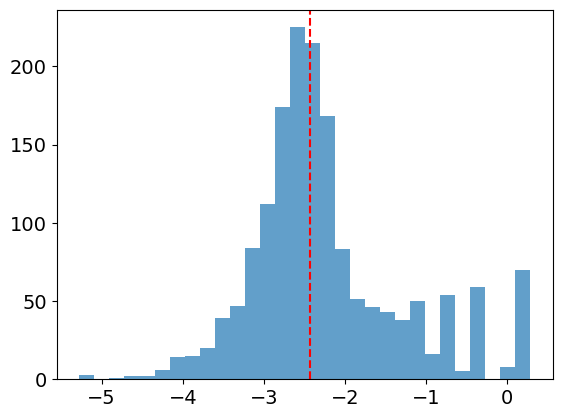

In [39]:
plt.hist(np.log10(np.abs(d_obs)), bins=30, alpha=0.7, label='Observed Data')
#also plot noise floor as vertical line
plt.axvline(np.log10(noise_floor), color='red', linestyle='--', label='Noise Floor')

## 4. True Model and Pseudosection

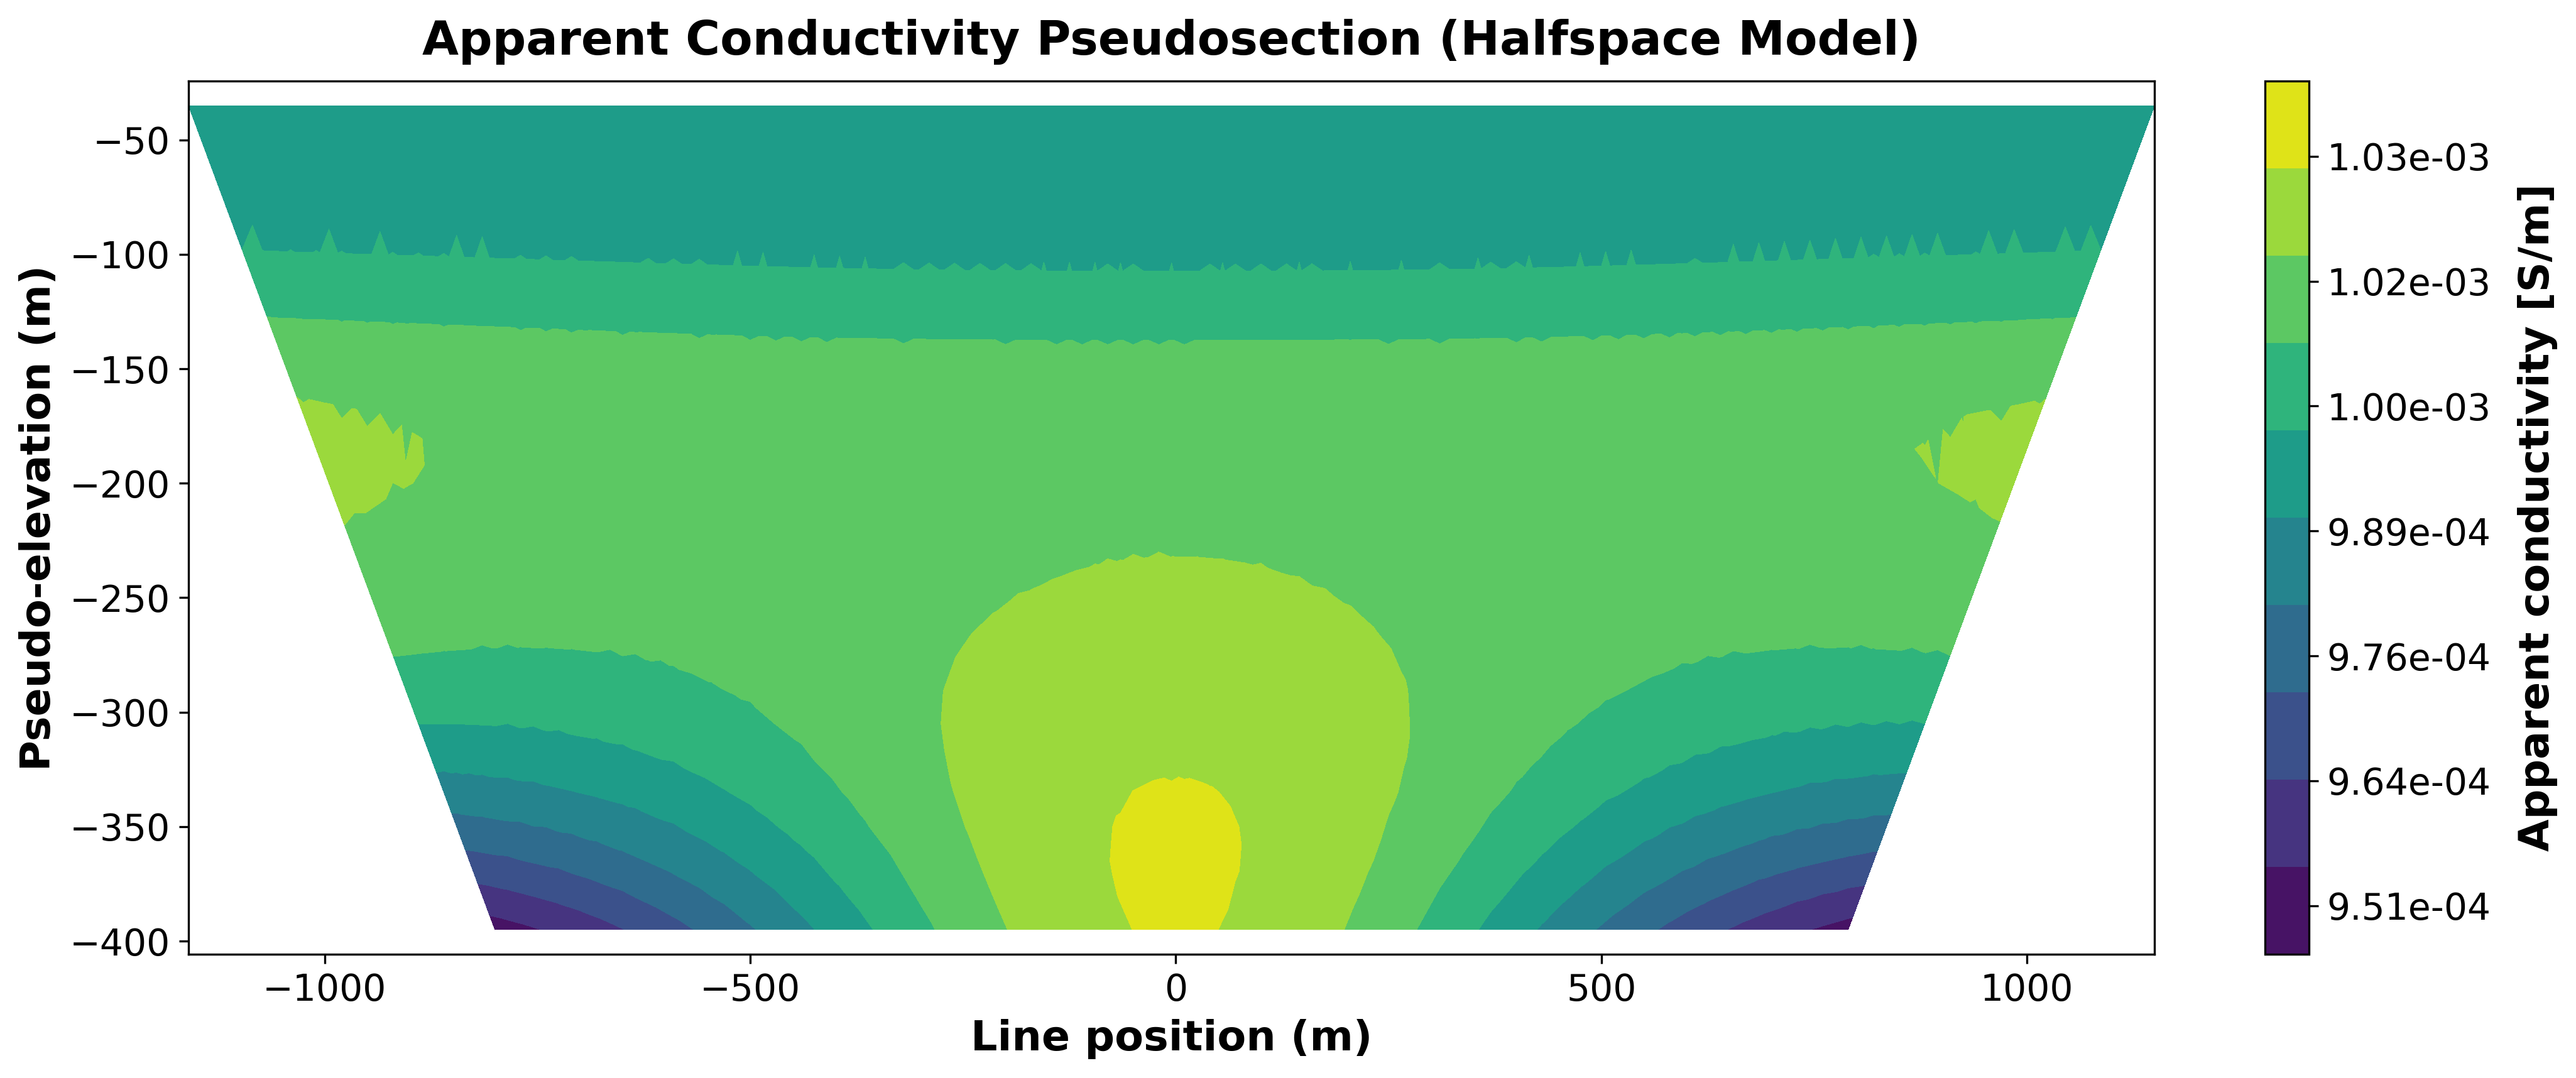

In [40]:
## SANITY CHECK: Halfspace forward modelling
halfspace_model = sigma_background * np.ones(mesh.nC)
halfspace_model[~active_cells] = sigma_air
dpred_halfspace = simulation.dpred(halfspace_model[active_cells])
apparent_conductivities = 1 / apparent_resistivity_from_voltage(survey, dpred_halfspace)
fig, ax = plt.subplots(figsize=(14, 6.0), dpi=300)

plot_pseudosection(
    survey,
    dobs=apparent_conductivities,
    plot_type="contourf",
    ax=ax,
    scale="log",
    cbar_label=r"Apparent conductivity [S/m]",
    mask_topography=False,
)
ax.set_title("Apparent Conductivity Pseudosection (Halfspace Model)", fontsize=18, fontweight="semibold")
plt.tight_layout()

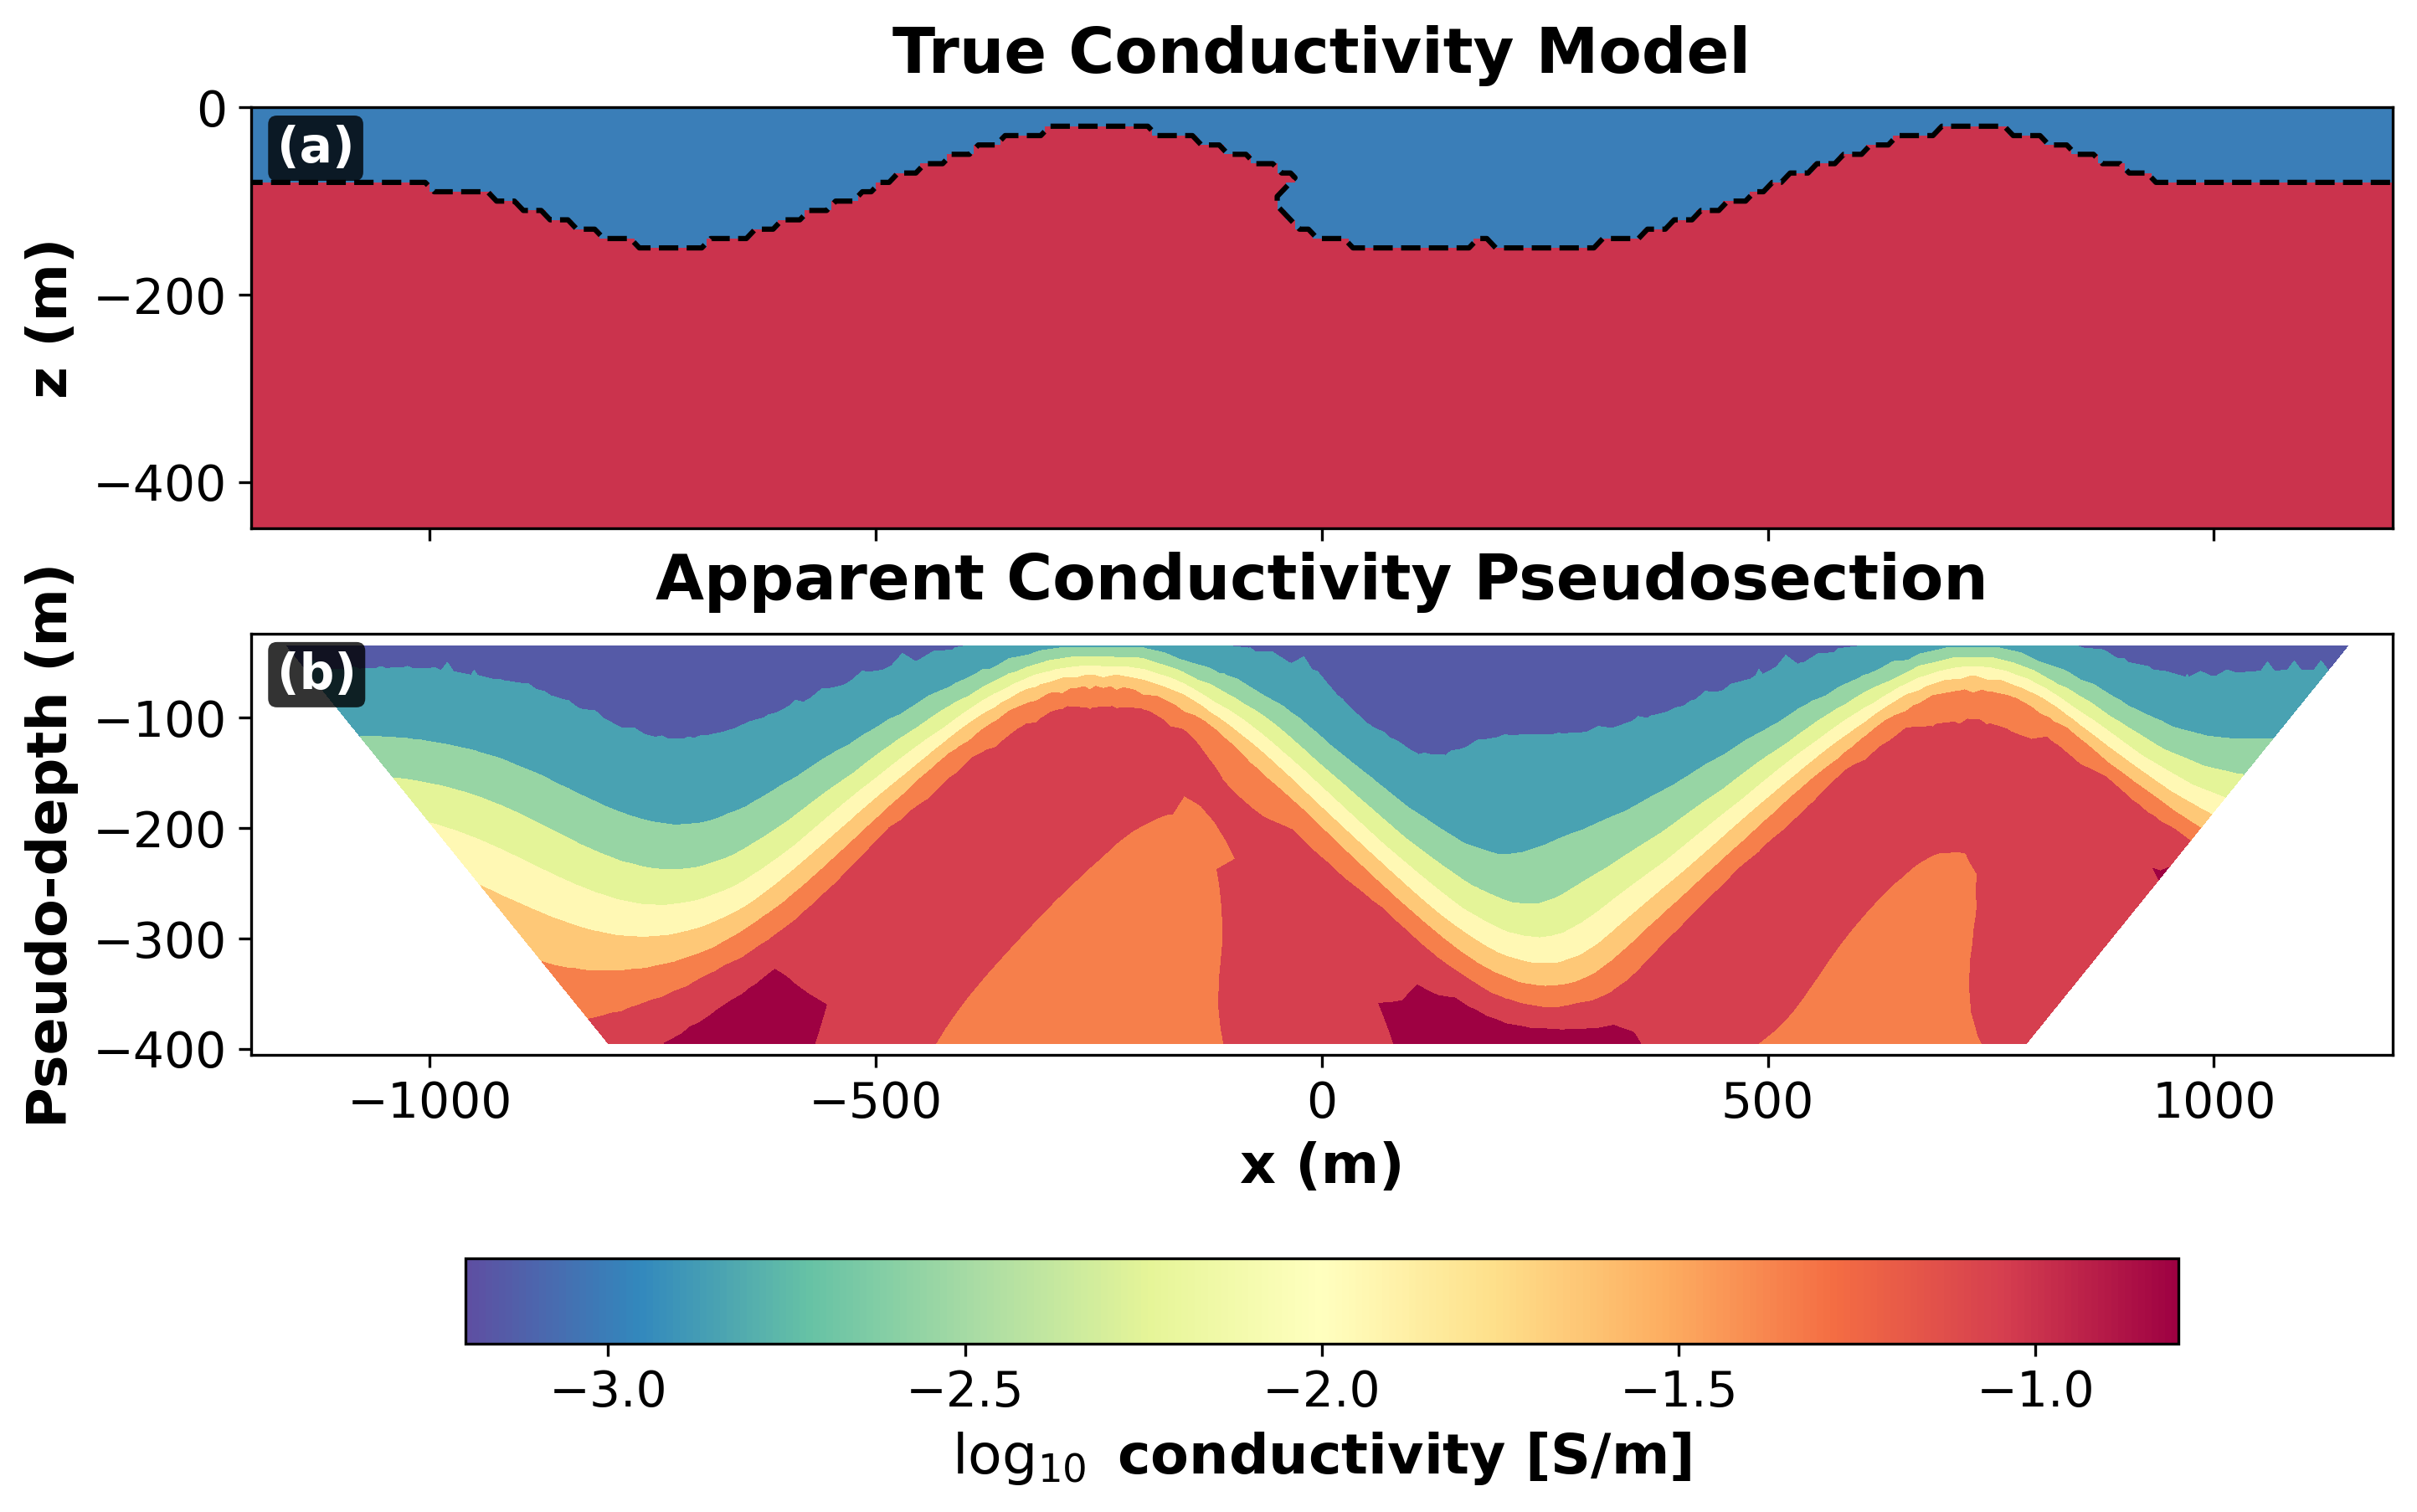

In [41]:
def plot_true_boundary(ax, color="black", lw=1.5):
    """Overlay the true basement + lens boundary as a contour."""
    cond_mask = basement_mask & ~lens_mask
    xg, zg = mesh.cell_centers_x, mesh.cell_centers_y
    grid = cond_mask.reshape((len(xg), len(zg)), order="F").T.astype(float)
    ax.contour(xg, zg, grid, levels=[0.5], colors=color,
               linewidths=lw, linestyles="--")


fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 7), dpi=300,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.25},
)

true_log10 = np.log10(np.exp(sigma_true))
out = mesh.plot_image(true_log10, ax=ax1, clim=(-3.2, -0.8))
out[0].set_cmap("Spectral_r")
plot_true_boundary(ax1)
ax1.set_ylabel("z (m)")
ax1.set_xlabel("")
ax1.set_title("True Conductivity Model", fontsize=18, fontweight="semibold")
ax1.set_xlim(end_locs)
ax1.tick_params(labelbottom=False)
ax1.text(0.012, 0.96, "(a)", transform=ax1.transAxes, ha="left", va="top",
         fontsize=14, fontweight="bold", color="white",
         bbox=dict(boxstyle="round,pad=0.18", facecolor="black",
                   edgecolor="none", alpha=0.8))

app_cond = 1.0 / apparent_resistivity_from_voltage(survey, d_clean)
plot_pseudosection(survey, dobs=np.log10(np.clip(app_cond, 1e-12, None)),
                   plot_type="contourf", ax=ax2, scale="linear",
                   clim=(-3.2, -0.8), create_colorbar=False,
                   contourf_opts={"cmap": "Spectral_r"}, mask_topography=False)
ax2.set_xlabel("x (m)")
ax2.set_ylabel("Pseudo-depth (m)")
ax2.set_title("Apparent Conductivity Pseudosection", fontsize=18, fontweight="semibold")
ax2.set_xlim(end_locs)
ax2.text(0.012, 0.96, "(b)", transform=ax2.transAxes, ha="left", va="top",
         fontsize=14, fontweight="bold", color="white",
         bbox=dict(boxstyle="round,pad=0.18", facecolor="black",
                   edgecolor="none", alpha=0.8))

cbar = fig.colorbar(out[0], ax=[ax1, ax2], label=r"$\log_{10}$ conductivity [S/m]",
                    orientation="horizontal", shrink=0.8)
cbar.ax.tick_params(labelsize=14)
#plt.tight_layout()
plt.show()

## 5. RBF Level-Set Parameterisation

In [42]:
def _sigma(alpha_raw):
    """Bounded shape coefficients"""
    return np.arctan(alpha_raw * 0.5)

def _sigma_prime(alpha_raw):
    """Derivative of bounded shape coefficients"""
    return 2.0 / (4.0 + alpha_raw ** 2)

# ------------------------------------------------------------------ #
def rbf_kernel(params, xyz, m, use_normalised_C=False, return_deriv=False):
    """
    RBF level-set kernel using sparse Gaussian RBF matrix.

    Parameters
    ----------
    params : list  [centres (N,d), eps, w_1, ..., w_N]
    xyz    : (n_active, d) array -- mesh cell centres (active only)
    m      : (N+2,) array -- [alpha_0, ..., alpha_{N-1}, c_low, c_high]
    use_normalised_C : bool -- normalise psi columns to unit L2 norm
    return_deriv : bool -- return (n_active, N+2) Jacobian if True
    """
    centres = np.asarray(params[0], dtype=np.float64)
    N       = centres.shape[0]
    eps     = float(params[1])
    rbf_w   = np.asarray(params[2:2+N], dtype=np.float64)
    xyz     = np.asarray(xyz, dtype=np.float64)

    c_low  = sigma_background#float(m[N])
    c_high = sigma_basement #float(m[N + 1])

    # ---- sparse Gaussian RBF matrix  psi(x) ----------------------------
    threshold      = 1e-12
    support_radius = rbf_w.max() * np.sqrt(-np.log(threshold))

    tree_xyz = cKDTree(xyz)
    tree_cen = cKDTree(centres)
    dist_coo = tree_xyz.sparse_distance_matrix(
        tree_cen, max_distance=support_radius, output_type="coo_matrix")

    w2 = (2*rbf_w[dist_coo.col]) ** 2
    psi_data = np.exp(-(dist_coo.data ** 2) / w2)

    keep = psi_data > threshold
    psi  = sp.csr_matrix(
        (psi_data[keep], (dist_coo.row[keep], dist_coo.col[keep])),
        shape=(xyz.shape[0], N))

    # column normalisation: each RBF column scaled to unit L2 norm
    # Ensures alpha coefficients are on a comparable scale across RBFs.
    if use_normalised_C:
        col_norms = np.asarray(psi.power(2).sum(axis=0)).flatten() ** 0.5
        col_norms = np.where(col_norms > 0, col_norms, 1.0)
        psi = psi @ sp.diags(1.0 / col_norms)

    # ---- level-set and Heaviside ---------------------------------
    alpha = _sigma(m[:N])           # bounded coefficients
    phi   = psi @ alpha             # level-set field
    arg   = (np.pi / eps) * phi
    H     = 0.5 + (1.0 / np.pi) * np.arctan(arg)

    # ---- physical property model ---------------------------------------
    f = c_low + (c_high - c_low) * H

    if not return_deriv:
        return f

    # Jacobian columns 0..N-1: df/d(alpha_j)
    H_prime     = 1.0 / (eps * (1.0 + arg ** 2))
    sigma_prime = _sigma_prime(m[:N])
    scale_row   = (c_high - c_low) * H_prime
    J_alpha = sp.diags(scale_row) @ psi @ sp.diags(sigma_prime)  # (n_pts, N)

    # Jacobian column N: df/d(c_low) = 1 - H  (dense column)
    #J_clow  = (1.0 - H).reshape(-1, 1)

    # Jacobian column N+1: df/d(c_high) = H  (dense column)
    #J_chigh = H.reshape(-1, 1)

    # Concatenate: result is (n_pts, N+2)
    J = sp.hstack([J_alpha], format="csr")#, sp.csr_matrix(J_clow)] #,sp.csr_matrix(J_chigh)], format="csr")
    return J


In [55]:
rbf_x = np.arange(core_x_domain[0], core_x_domain[1] + rbf_spacing / 2, rbf_spacing)
rbf_z = np.arange(z_min, z_top + rbf_spacing/2, rbf_spacing_z)
rbf_xx, rbf_zz = np.meshgrid(rbf_x, rbf_z)
rbf_inner_centres = np.c_[rbf_xx.ravel(), rbf_zz.ravel()]

edge_x_left = np.arange(x_domain[0], core_x_domain[0], rbf_edge_spacing)
edge_x_right = np.unique(np.r_[np.arange(core_x_domain[1] + rbf_edge_spacing, x_domain[1], rbf_edge_spacing), x_domain[1]])
edge_z = np.arange(z_min, z_top, rbf_edge_spacing)
edge_z = np.unique(np.r_[edge_z, z_top]) if edge_z.size else np.array([z_min, z_top])

left_edge = np.c_[np.repeat(edge_x_left, edge_z.size), np.tile(edge_z, edge_x_left.size)]
right_edge = np.c_[np.repeat(edge_x_right, edge_z.size), np.tile(edge_z, edge_x_right.size)]
edge_centres = np.vstack([left_edge, right_edge]) if left_edge.size and right_edge.size else np.vstack([left_edge, right_edge,])

rbf_centres = np.vstack([rbf_inner_centres, edge_centres])
n_rbf = rbf_centres.shape[0]

# find indices of edge centres in the full list of RBF centres
edge_tree = cKDTree(edge_centres)
#_, edge_indices = edge_tree.query(rbf_centres)
edge_indices = np.arange(rbf_inner_centres.shape[0], n_rbf)

rbf_widths = np.full(n_rbf, rbf_width_factor * rbf_spacing)
extra_params = [rbf_centres, eps_init] + list(rbf_widths)

alpha_init = -1.0 * np.ones(n_rbf)
alpha_init[edge_indices] = -5.0
clow = np.log(1e-3)
chigh = sigma_basement
params_init = np.r_[alpha_init.copy()]#, clow] #, chigh]
n_params = len(params_init)

param_map = maps.ParametricRBFMapping(
    mesh=mesh, nP=n_params, active_cells=active_cells,
    forward_transform=rbf_kernel, params=extra_params,
)
print("Total RBF centres: {} ({} inner + {} edge)".format(
    n_rbf, rbf_inner_centres.shape[0], edge_centres.shape[0]
))
print("Total params", n_params)

Total RBF centres: 255 (231 inner + 24 edge)
Total params 255


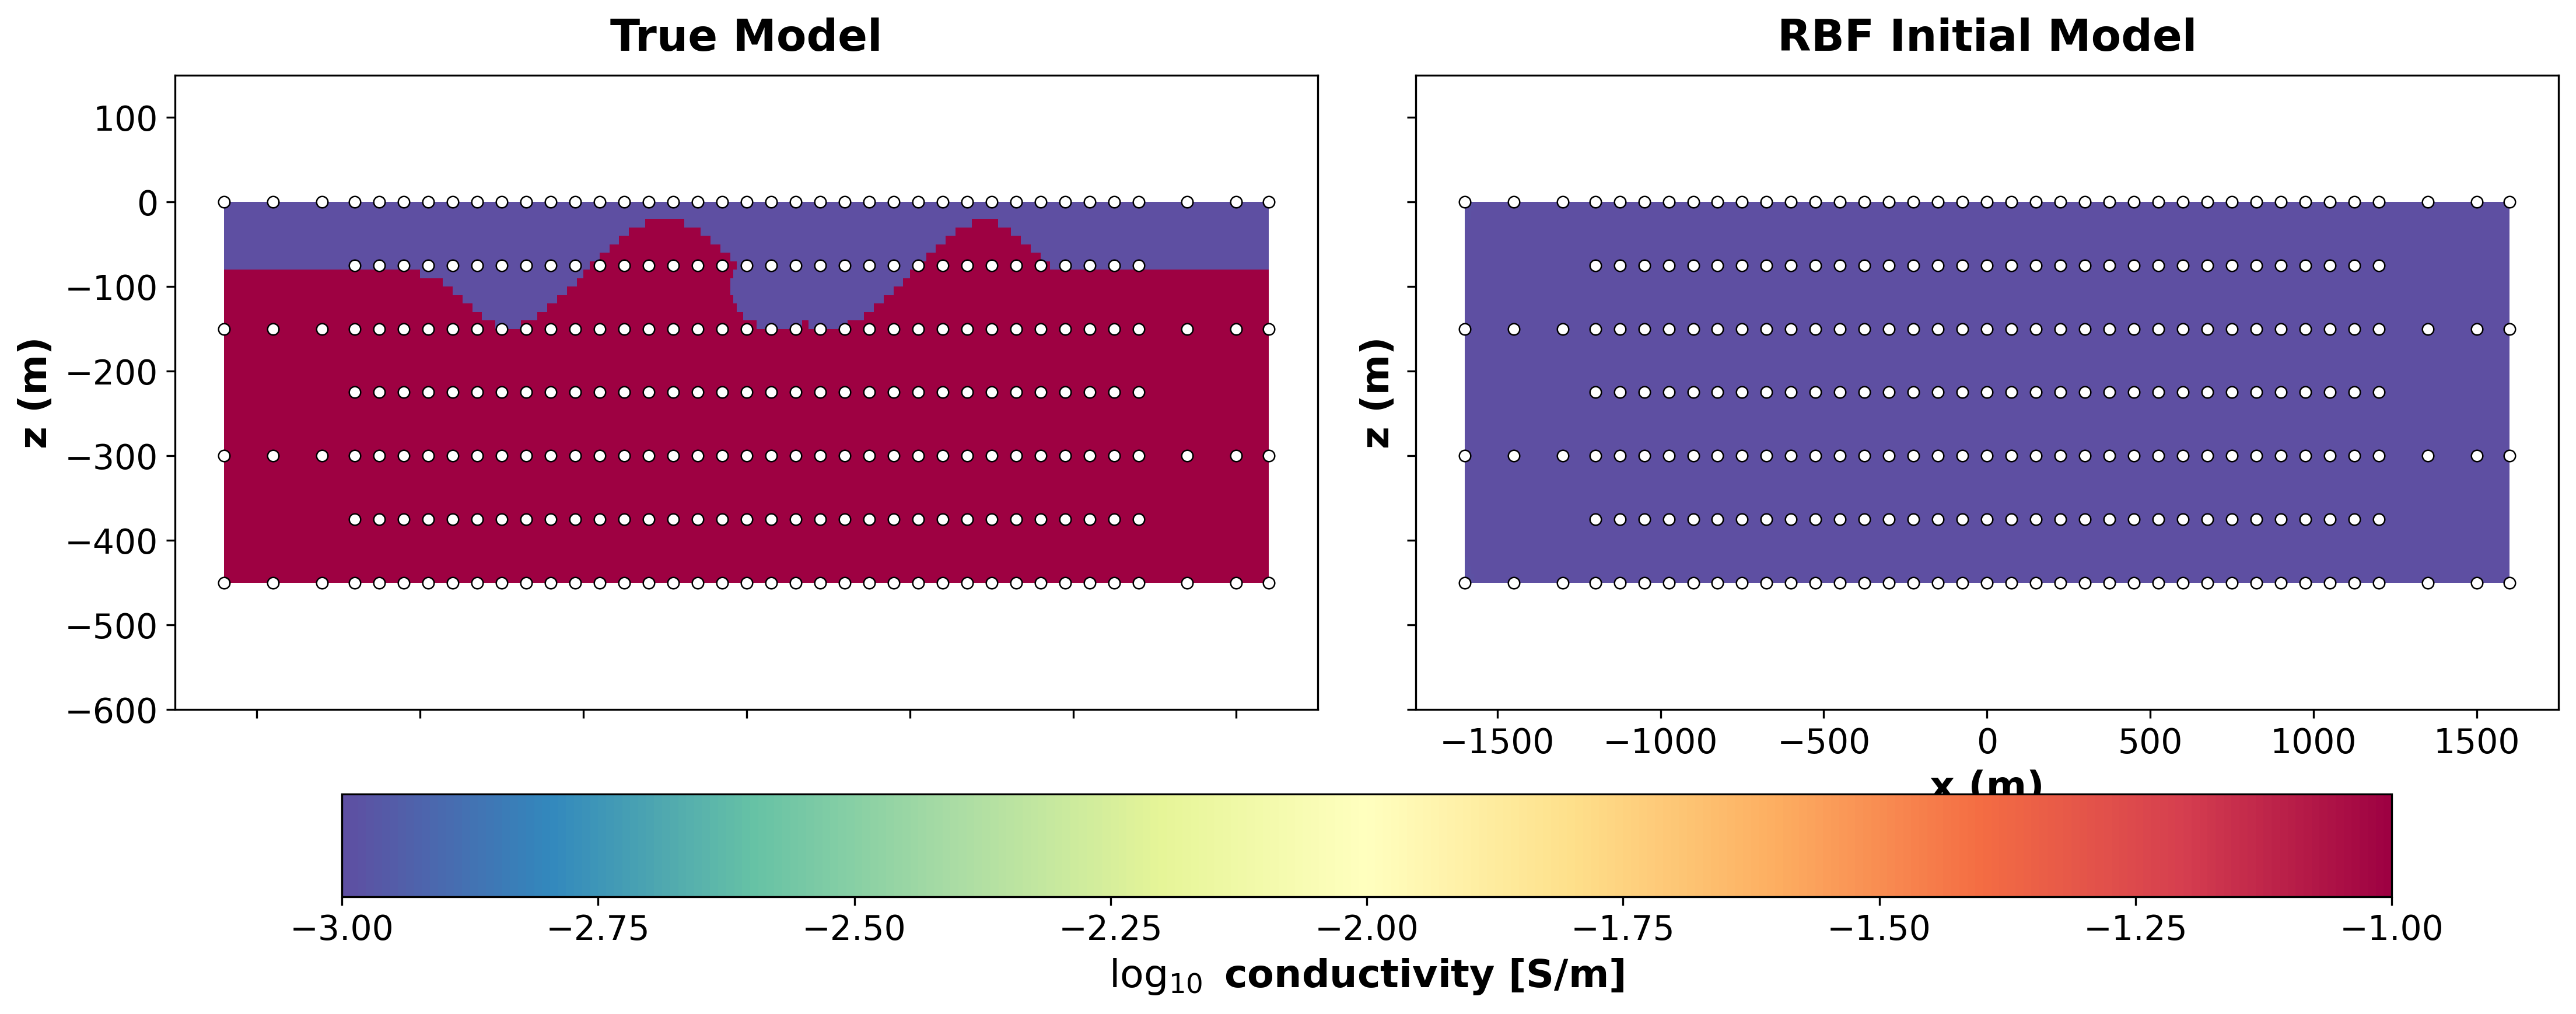

In [56]:
sigma_rbf_init = sim_map * param_map * params_init
true_log10 = np.log10(np.exp(sigma_true))
rbf_init_log10 = np.log10(np.clip(sigma_rbf_init, 1e-12, None))

clim = (
    np.nanpercentile(np.hstack([true_log10, rbf_init_log10]), 2),
    np.nanpercentile(np.hstack([true_log10, rbf_init_log10]), 98),
)

fig, axes = plt.subplots(1, 2, figsize=(15.0, 6.2), dpi=300, sharex=True, sharey=True)
fig.patch.set_facecolor("white")

for ax, data, title in [
    (axes[0], true_log10, "True Model"),
    (axes[1], rbf_init_log10, "RBF Initial Model"),
]:
    out = mesh.plot_image(data, ax=ax, clim=clim)
    out[0].set_cmap("Spectral_r")
    ax.scatter(
        rbf_centres[:, 0], rbf_centres[:, 1],
        s=22, facecolors="white", edgecolors="black", linewidths=0.6, zorder=10
    )
    ax.set_aspect("auto")
    ax.set_xlim(x_domain[0] - rbf_edge_spacing, x_domain[1] + rbf_edge_spacing)
    ax.set_ylim(z_min - rbf_edge_spacing, z_top + rbf_edge_spacing)
    ax.set_title(title, fontsize=18, fontweight="semibold")
    ax.set_ylabel("z (m)")
    ax.tick_params(axis="both", which="major", labelsize=14)

axes[0].set_xlabel("")
axes[0].tick_params(labelbottom=False)
axes[1].set_xlabel("x (m)")
plt.tight_layout()
cbar = fig.colorbar(out[0], ax=axes.ravel().tolist(), orientation="horizontal", shrink=0.86, pad=0.10)
cbar.set_label(r"$\log_{10}$ conductivity [S/m]", fontweight="bold")
cbar.ax.tick_params(labelsize=14)
plt.show()

## 6. L2 Smooth Inversion (Baseline)

In [ ]:
dmisfit_l2 = data_misfit.L2DataMisfit(
    data=simpeg_data.Data(survey, dobs=d_obs, standard_deviation=std),
                          
    simulation=simulation,
)

reg_l2 = regularization.WeightedLeastSquares(mesh=mesh, active_cells=active_cells)
opt_l2 = optimization.ProjectedGNCG(
    maxIter=50, maxIterLS=50, maxIterCG=30,
    lower=np.log(5e-4) * np.ones(active_cells.sum()),
    upper=np.log(1e0) * np.ones(active_cells.sum()),
)

save_l2 = directives.SaveOutputEveryIteration(save_txt=False)
inv_prob_l2 = inverse_problem.BaseInvProblem(dmisfit_l2, reg_l2, opt_l2)
inv_l2 = inversion.BaseInversion(inv_prob_l2, directiveList=[    directives.BetaEstimate_ByEig(beta0_ratio=1e1),
    directives.BetaSchedule(coolingFactor=2.0, coolingRate=1),
    directives.TargetMisfit(chifact=1.0),
    save_l2,])

m0_l2 = sigma_background * np.ones(active_cells.sum())
m_l2 = inv_l2.run(m0_l2)
sigma_l2 = sim_map * m_l2
print("L2 inversion complete.")
np.save("/t40array/ppokar/parametric/thesis/results/dcr_d2b_l2.npy", sigma_l2)

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.0


INFO: Directive TargetMisfit: Target data misfit is 1650.0


================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.78e+01  9.68e+04  0.00e+00  9.68e+04                         0           inf          inf                
   1  1.78e+01  6.03e+04  8.80e+02  7.60e+04    2.52e+02      0      7        5.06e-08     8.72e-04              
   2  8.90e+00  4.90e+04  1.88e+03  6.58e+04    2.15e+02      0      8        3.19e-08     1.38e-04   Skip BFGS  
   3  4.45e+00  3.77e+04  3.84e+03  5.48e+04    2.14e+02      0      9        9.93e-08     3.57e-04   Skip BFGS  
   4  2.22e+00  2.89e+04  6.90e+03  4.43e+04    2.08e+02      0      10       2.56e-07     6.34e-04   Skip BFGS  
   5  1.11e+00  2.23e+04  1.15e+04  3.51e+04    1.99e+02      0      12       2.44e-07 

FileNotFoundError: [Errno 2] No such file or directory: 't40array/ppokar/parametric/thesis/results/dcr_d2b_l2.npy'

In [ ]:
np.save("/t40array/ppokar/parametric/thesis/results/dcr_d2b_l2.npy", sigma_l2)

## 7. RBF Level-Set Inversion

In [45]:
lower_rbf = np.r_[-10.0 * np.ones_like(alpha_init)]#, np.log(1e-6)] # , np.log(1e-2)]
lower_rbf[edge_indices] = -10.0
upper_rbf = np.r_[10.0 * np.ones_like(alpha_init)]#, np.log(1e-3)] #, np.log(1e1)]
upper_rbf[edge_indices] = -9.5  # force edge RBFs
simulation_rbf = dc.Simulation2DNodal(
    mesh, survey=survey, sigmaMap=sim_map * param_map,
)

dmisfit_rbf = data_misfit.L2DataMisfit(
    data=simpeg_data.Data(survey, dobs=d_obs, standard_deviation=std,),
    simulation=simulation_rbf,
)

reg_rbf = regularization.WeightedLeastSquares(
    mesh=TensorMesh([np.ones(n_params)]),
)

opt_rbf = optimization.ProjectedGNCG(
    maxIter=50, maxIterLS=50, maxIterCG=30,
    lower=lower_rbf,
    upper=upper_rbf,
)
save_rbf = directives.SaveOutputEveryIteration(save_txt=False)
inv_prob_rbf = inverse_problem.BaseInvProblem(dmisfit_rbf, reg_rbf, opt_rbf, beta=0)  
inv_rbf = inversion.BaseInversion(inv_prob_rbf, directiveList=[directives.TargetMisfit(chifact=1.0),
    save_rbf,])

m_rbf = inv_rbf.run(params_init.copy())
sigma_rbf = sim_map * param_map * m_rbf
print("RBF inversion complete.")


INFO: Setting the default solver 'Pardiso' for the 'Simulation2DNodal'.
To avoid receiving this message, pass a solver to the simulation. For example:

  from simpeg.utils import get_default_solver

  solver = get_default_solver()
  simulation = Simulation2DNodal(solver=solver, ...)
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2
using the same solver as the Simulation2DNodal simulation with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 1650.0



Running inversion with SimPEG v0.25.0
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  0.00e+00  9.38e+04  5.58e+02  9.38e+04                         0           inf          inf                
   1  0.00e+00  8.15e+04  4.76e+03  8.15e+04    8.11e+01      6      30       1.20e-02     4.70e+00              
   2  0.00e+00  3.93e+04  5.40e+03  3.93e+04    1.35e+02      1      30       1.42e-02     1.60e+02              
   3  0.00e+00  2.92e+04  5.11e+03  2.92e+04    1.26e+02      1      30       4.93e-02     6.26e+02              
   4  0.00e+00  2.04e+04  4.84e+03  2.04e+04    1.23e+02      0      30       7.93e-02     1.41e+03              
   5  0.00e+00  5.61e+03  4.85e+03  5.61e+03    

## 8. Comparison Figure

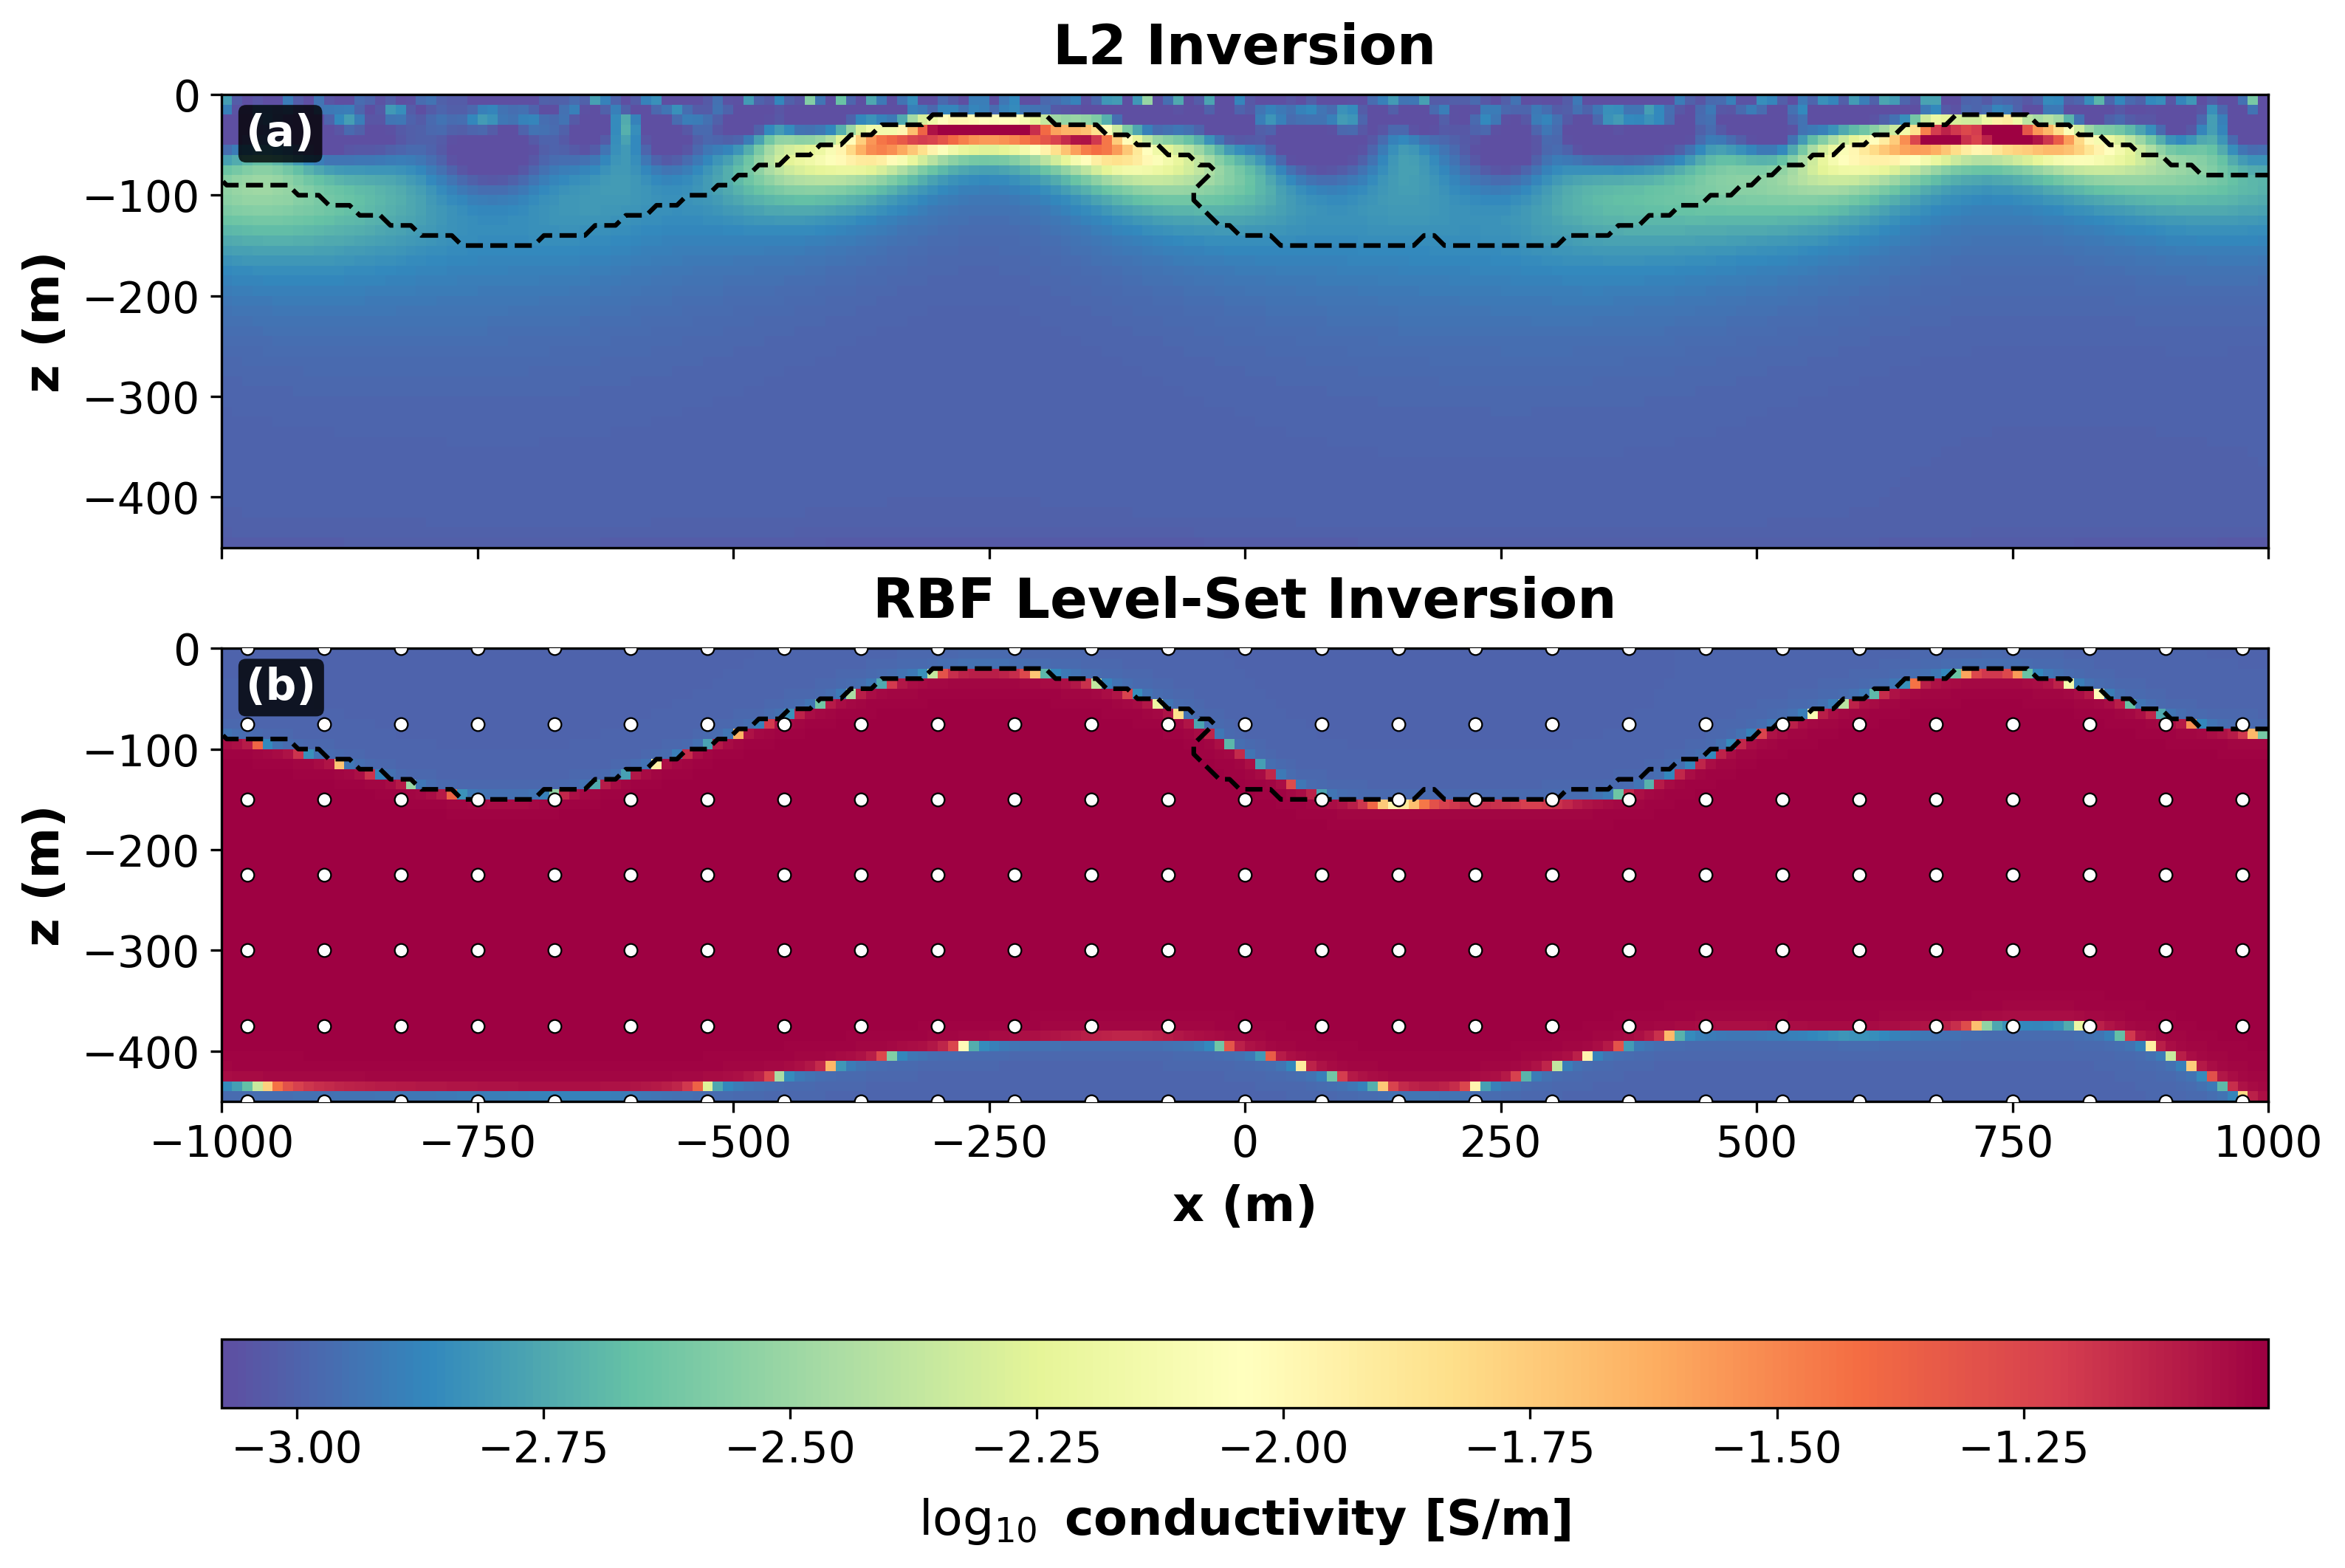

In [52]:
l2_log10 = np.log10(sigma_l2)
rbf_log10 = np.log10(sigma_rbf)
clim = (np.log10(1e-3), np.log10(1e-1))
clim = (np.nanpercentile(np.hstack([l2_log10, rbf_log10]), 2),
        np.nanpercentile(np.hstack([l2_log10, rbf_log10]), 98))

fig = plt.figure(figsize=(10.5, 7.6), dpi=300)
gs = fig.add_gridspec(
    4, 1, height_ratios=[1, 1, 0.08, 0.15], hspace=0.40,
    left=0.10, right=0.98, top=0.96, bottom=0.18,
)
ax_l2 = fig.add_subplot(gs[0])
ax_rbf = fig.add_subplot(gs[1], sharex=ax_l2)
spacer_ax = fig.add_subplot(gs[2])
cbar_ax = fig.add_subplot(gs[3])
spacer_ax.axis("off")

for ax, data, title, label in [
    (ax_l2, l2_log10, "L2 Inversion", "(a)"),
    (ax_rbf, rbf_log10, "RBF Level-Set Inversion", "(b)"),
]:
    out = mesh.plot_image(data, ax=ax, clim=clim)
    out[0].set_cmap("Spectral_r")
    ax.set_aspect("auto")
    ax.set_xlim(-1000, 1000)
    ax.set_ylim(z_min, z_top)
    ax.set_ylabel("z (m)")
    ax.set_title(title, fontsize=18, fontweight="semibold")
    plot_true_boundary(ax)
    ax.text(0.012, 0.96, label, transform=ax.transAxes, ha="left", va="top",
            fontsize=14, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.18", facecolor="black",
                      edgecolor="none", alpha=0.8))

ax_rbf.scatter(rbf_centres[:, 0], rbf_centres[:, 1], s=18,
               facecolors="white", edgecolors="black", linewidths=0.55, zorder=10)
ax_l2.tick_params(labelbottom=False)
ax_rbf.set_xlabel("x (m)", labelpad=6)
ax_l2.set_xlabel("")
cbar = fig.colorbar(out[0], cax=cbar_ax, orientation="horizontal")
cbar.set_label(r"$\log_{10}$ conductivity [S/m]", labelpad=8, fontweight="bold")
cbar.ax.tick_params(labelsize=14)
plt.show()

In [47]:
# ------------------------------------------------------------
# Data-fit comparison 
# ------------------------------------------------------------
dpred_true = d_obs                      
dpred_l2   = simulation.dpred(m_l2)      
dpred_rbf  = simulation_rbf.dpred(m_rbf) 

# Apparent conductivity from predicted voltages
app_true = 1.0 / apparent_resistivity_from_voltage(survey, dpred_true)
app_l2   = 1.0 / apparent_resistivity_from_voltage(survey, dpred_l2)
app_rbf  = 1.0 / apparent_resistivity_from_voltage(survey, dpred_rbf)

# Normalized residuals
residual_l2  = (d_obs - dpred_l2)  / std
residual_rbf = (d_obs - dpred_rbf) / std
resid_lim = np.nanpercentile(np.abs(np.r_[residual_l2, residual_rbf]), 98)
resid_lim = max(resid_lim, 1.0)


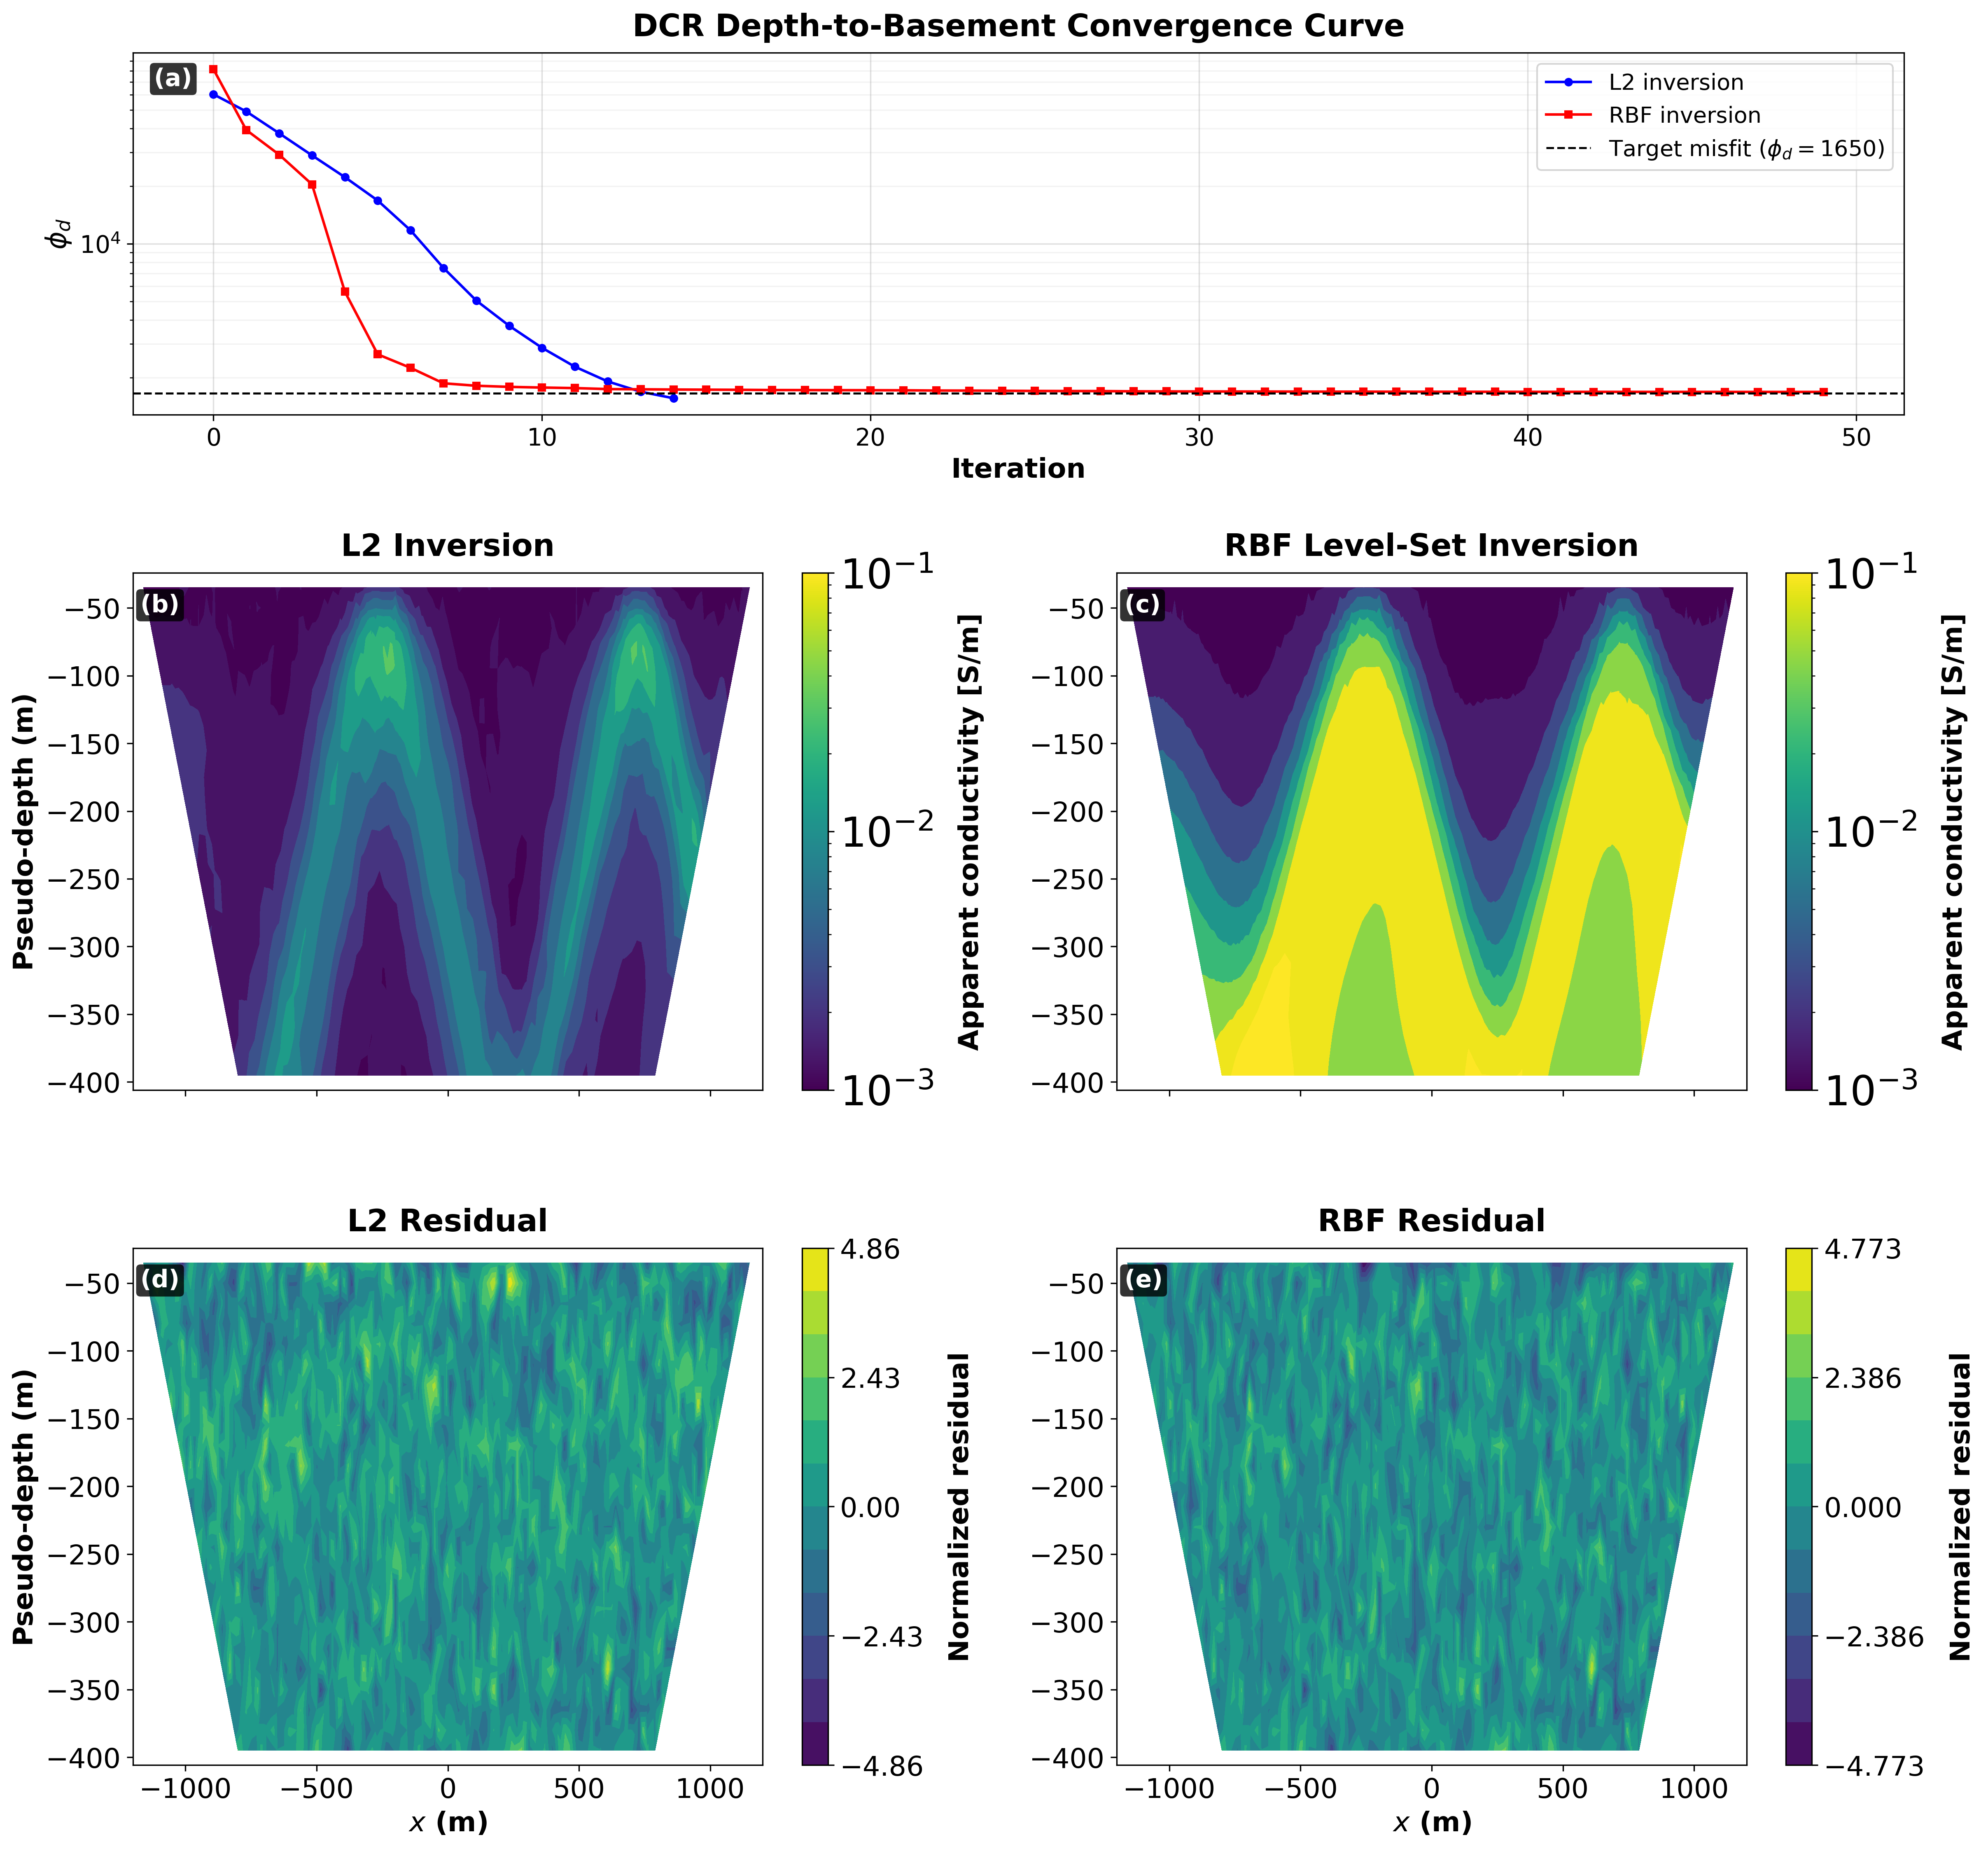

In [58]:
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

phid_l2  = np.asarray(save_l2.phi_d)
phid_rbf = np.asarray(save_rbf.phi_d)
target_misfit = survey.nD

cond_clim  = (1e-3, 1e-1)
lim_l2  = np.nanmax(np.abs(residual_l2))
lim_rbf = np.nanmax(np.abs(residual_rbf))

fig = plt.figure(figsize=(18.5, 18.0), dpi=300)
fig.patch.set_facecolor("white")
gs = fig.add_gridspec(
    nrows=3, ncols=2,
    height_ratios=[0.7, 1.0, 1.0],
    hspace=0.34, wspace=0.25,
)

ax_conv   = fig.add_subplot(gs[0, :])
ax_l2     = fig.add_subplot(gs[1, 0])
ax_rbf    = fig.add_subplot(gs[1, 1])
ax_l2_f   = fig.add_subplot(gs[2, 0])
ax_rbf_f  = fig.add_subplot(gs[2, 1])

# ------------------------------------------------------------------ #
# Panel (a): convergence curve
# ------------------------------------------------------------------ #
it_l2  = np.arange(phid_l2.size)
it_rbf = np.arange(phid_rbf.size)

ax_conv.semilogy(it_l2,  phid_l2,  "b-o", ms=4, lw=1.5, label="L2 inversion")
ax_conv.semilogy(it_rbf, phid_rbf, "r-s", ms=4, lw=1.5, label="RBF inversion")
ax_conv.axhline(target_misfit, color="k", ls="--", lw=1.2,
                 label=rf"Target misfit ($\phi_d = {target_misfit:.0f}$)")

ax_conv.yaxis.set_major_locator(LogLocator(base=10, numticks=10))
ax_conv.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=50))
ax_conv.yaxis.set_minor_formatter(NullFormatter())

ax_conv.set_xlabel("Iteration", fontsize=16)
ax_conv.set_ylabel(r"$\phi_d$", fontsize=16)
ax_conv.set_title("DCR Depth-to-Basement Convergence Curve", fontsize=18, fontweight="semibold", pad=10)
ax_conv.legend(fontsize=13, loc="upper right")
ax_conv.grid(True, which="major", alpha=0.4)
ax_conv.grid(True, which="minor", alpha=0.15)
ax_conv.tick_params(axis="both", which="major", labelsize=14)
ax_conv.text(0.012, 0.96, "(a)", transform=ax_conv.transAxes, ha="left", va="top",
             fontsize=14, fontweight="bold", color="white",
             bbox=dict(boxstyle="round,pad=0.18", facecolor="black",
                       edgecolor="none", alpha=0.8))

psec_common = dict(plot_type="contourf", mask_topography=False)

plots = [
    (ax_l2,    app_l2,   "L2 Inversion",              "log",
     dict(clim=cond_clim, cbar_label=r"Apparent conductivity [S/m]"), "(b)"),
    (ax_rbf,   app_rbf,  "RBF Level-Set Inversion",   "log",
     dict(clim=cond_clim, cbar_label=r"Apparent conductivity [S/m]"), "(c)"),

    (ax_l2_f,  residual_l2,  "L2 Residual",  "linear",
     dict(clim=(-lim_l2, lim_l2), cmap="RdBu_r",
          cbar_label=r"Normalized residual",
          contourf_opts=dict(levels=np.linspace(-lim_l2, lim_l2, 13))), "(d)"),
    (ax_rbf_f, residual_rbf, "RBF Residual", "linear",
     dict(clim=(-lim_rbf, lim_rbf), cmap="RdBu_r",
          cbar_label=r"Normalized residual",
          contourf_opts=dict(levels=np.linspace(-lim_rbf, lim_rbf, 13))), "(e)"),
]

def _format_log10_tick(value, _pos=None):
    if value <= 0 or not np.isfinite(value):
        return ""
    exp = int(np.round(np.log10(value)))
    return rf"$10^{{{exp:d}}}$"

def _get_mappable(ax):
    if ax.collections:
        return ax.collections[0]
    if ax.images:
        return ax.images[0]
    return None

def _format_cond_colorbar(cbar):
    vmin, vmax = cbar.mappable.get_clim()
    mid = 10 ** ((np.log10(vmin) + np.log10(vmax)) / 2.0)
    cbar.set_ticks([vmin, mid, vmax])
    cbar.formatter = FuncFormatter(_format_log10_tick)
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=24)
    cbar.ax.yaxis.labelpad = 14

def _format_resid_colorbar(cbar, nticks=5):
    vmin, vmax = cbar.mappable.get_clim()
    cbar.set_ticks(np.linspace(vmin, vmax, nticks))
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.yaxis.labelpad = 14

cond_axes  = (ax_l2, ax_rbf)
left_col   = (ax_l2, ax_l2_f)
bottom_row = (ax_l2_f, ax_rbf_f)

for ax, values, title, scale, extra, panel in plots:
    plot_pseudosection(
        survey, dobs=values, ax=ax, scale=scale,
        create_colorbar=False, **psec_common, **extra,
    )
    ax.set_title(title, fontsize=18, fontweight="semibold", pad=10)
    ax.text(0.012, 0.96, panel, transform=ax.transAxes, ha="left", va="top",
            fontsize=14, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.18", facecolor="black",
                      edgecolor="none", alpha=0.8))
    ax.tick_params(axis="both", which="major", labelsize=16)
    ax.set_xlim(end_locs[0], end_locs[1])

    if ax in cond_axes:
        sm = ScalarMappable(norm=LogNorm(*cond_clim), cmap="viridis")
        cbar = fig.colorbar(sm, ax=ax)
        _format_cond_colorbar(cbar)
    else:
        mappable = _get_mappable(ax)
        cbar = fig.colorbar(mappable, ax=ax) if mappable is not None else None
        if cbar is not None:
            _format_resid_colorbar(cbar, nticks=5)

    if cbar is not None:
        cbar_label = extra.get("cbar_label")
        if cbar_label:
            cbar.set_label(cbar_label)

for ax in (ax_l2, ax_rbf, ax_l2_f, ax_rbf_f):
    ax.set_ylabel(r"Pseudo-depth (m)" if ax in left_col else "", fontsize=16)
    if ax in bottom_row:
        ax.set_xlabel(r"$x$ (m)", fontsize=16)
    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelbottom=False)

plt.show()


In [57]:
print(f"{save_rbf.phi_d[-1]:.2f}  chi2n={save_rbf.phi_d[-1]/survey.nD:.4f}")
print(f"{save_l2.phi_d[-1]:.2f}")

1680.75  chi2n=1.0186
1558.09
